In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
import random
AUTO = tf.data.AUTOTUNE

In [2]:
# CONFIG
DATA_DIR = "/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Train"  # Change this to your dataset path
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 2 # Change to 2 for binary classification
EPOCHS = 20

In [3]:
# Load and Preprocess Dataset
def decode_img(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img

def process_path(file_path, label):
    img = decode_img(file_path)
    return img, label

def prepare_dataset(data_dir):
    classes = sorted(os.listdir(data_dir))
    file_paths, labels = [], []
    for i, cls in enumerate(classes):
        class_path = os.path.join(data_dir, cls)
        for img_file in sorted(os.listdir(class_path)):
            if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
                continue
            file_paths.append(os.path.join(class_path, img_file))
            labels.append(i)

    lb = LabelBinarizer()
    one_hot_labels = lb.fit_transform(labels)
    if NUM_CLASSES == 2 and one_hot_labels.shape[1] == 1:
        one_hot_labels = np.concatenate([1 - one_hot_labels, one_hot_labels], axis=1)
    return file_paths, one_hot_labels, lb

file_paths, labels, label_binarizer = prepare_dataset(DATA_DIR)

combined = list(zip(file_paths, labels))
random.shuffle(combined)
file_paths, labels = zip(*combined)
file_paths = list(file_paths)
labels = np.array(labels)
split_idx = int(len(file_paths) * 0.8)
train_paths, val_paths = file_paths[:split_idx], file_paths[split_idx:]
train_labels, val_labels = labels[:split_idx], labels[split_idx:]

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))

train_ds = train_ds.map(process_path, num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)
val_ds = val_ds.map(process_path, num_parallel_calls=AUTO).batch(BATCH_SIZE).prefetch(AUTO)

In [4]:
# Build ViT v2 Model using Hugging Face Transformers
from transformers import ViTFeatureExtractor, TFViTModel

feature_extractor = ViTFeatureExtractor.from_pretrained("google/vit-base-patch16-224-in21k")
vit_encoder = TFViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
vit_encoder.trainable = False

def build_vit_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = layers.Rescaling(1./255)(inputs)
    x = layers.Lambda(lambda x: tf.image.resize(x, (224, 224)))(x)
    x = tf.transpose(x, perm=[0, 3, 1, 2])  # Transpose to (batch_size, channels, height, width)
    x = vit_encoder(x, training=False).last_hidden_state[:, 0, :]
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

model = build_vit_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/models/vit/feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFViTModel.

All the weights of TFViTModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFViTModel for predictions without further training.


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 lambda (Lambda)             (None, 224, 224, 3)       0         
                                                                 
 tf.compat.v1.transpose (TF  (None, 3, 224, 224)       0         
 OpLambda)                                                       
                                                                 
 tf_vi_t_model (TFViTModel)  TFBaseModelOutputWithPo   86389248  
                             oling(last_hidden_state             
                             =(None, 197, 768),                  
                              pooler_output=(None, 7         

In [5]:
# Train
early_stop = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[early_stop])

Epoch 1/20
54/54 [==============================] - 35s 394ms/step - loss: 0.4645 - accuracy: 0.7858 - val_loss: 0.3886 - val_accuracy: 0.8275
Epoch 2/20
54/54 [==============================] - 17s 319ms/step - loss: 0.3066 - accuracy: 0.8722 - val_loss: 0.2952 - val_accuracy: 0.8741
Epoch 3/20
54/54 [==============================] - 17s 318ms/step - loss: 0.2406 - accuracy: 0.9083 - val_loss: 0.2217 - val_accuracy: 0.9231
Epoch 4/20
54/54 [==============================] - 17s 319ms/step - loss: 0.1817 - accuracy: 0.9335 - val_loss: 0.1904 - val_accuracy: 0.9324
Epoch 5/20
54/54 [==============================] - 17s 319ms/step - loss: 0.1506 - accuracy: 0.9445 - val_loss: 0.1750 - val_accuracy: 0.9347
Epoch 6/20
54/54 [==============================] - 17s 319ms/step - loss: 0.1181 - accuracy: 0.9626 - val_loss: 0.1576 - val_accuracy: 0.9464
Epoch 7/20
54/54 [==============================] - 17s 319ms/step - loss: 0.1002 - accuracy: 0.9726 - val_loss: 0.1327 - val_accuracy: 0.9557

In [6]:
# Evaluate
val_images, val_true = [], []
for img_batch, label_batch in val_ds:
    val_images.append(img_batch.numpy())
    val_true.append(label_batch.numpy())
val_images = np.concatenate(val_images)
val_true = np.concatenate(val_true)
val_preds = model.predict(val_images, batch_size=BATCH_SIZE)
print(classification_report(np.argmax(val_true, axis=1), np.argmax(val_preds, axis=1)))

14/14 [==============================] - 6s 244ms/step
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       196
           1       0.98      0.99      0.98       233

    accuracy                           0.98       429
   macro avg       0.98      0.98      0.98       429
weighted avg       0.98      0.98      0.98       429



In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize

def plot_roc_curve(model, val_ds, y_true, num_classes):
    y_pred = model.predict(val_ds)
    
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(y_true[:, 1], y_pred[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(6, 6))
        plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend()
        plt.grid()
        plt.show()
    else:
        y_true = label_binarize(y_true.argmax(axis=1), classes=list(range(num_classes)))
        y_pred = y_pred
        plt.figure(figsize=(8, 6))
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(y_true[:, i], y_pred[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Multiclass ROC Curve')
        plt.legend()
        plt.grid()
        plt.show()

14/14 [==============================] - 6s 240ms/step


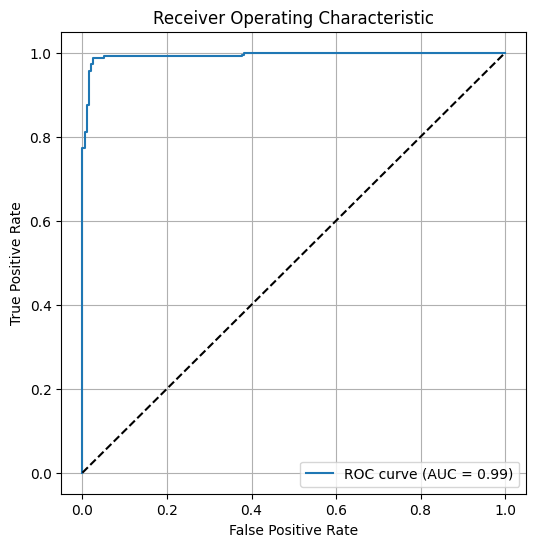

In [8]:
plot_roc_curve(model, val_ds, val_labels, NUM_CLASSES)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`ViTSdpaAttention` is used but `torch.nn.functional.scaled_dot_product_attention` does not support `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.


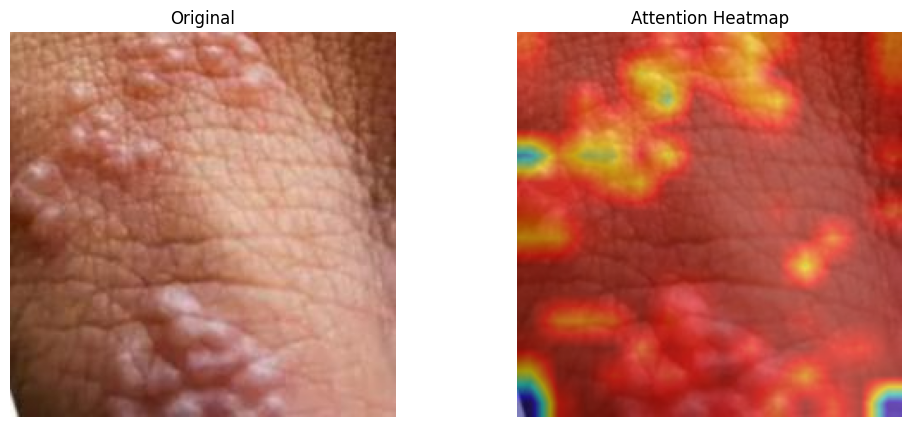

In [22]:
import torch
from transformers import ViTModel, ViTImageProcessor
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load pretrained Hugging Face ViT base model (without classification head)
model = ViTModel.from_pretrained("google/vit-base-patch16-224")
model.eval()

# Image processor
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")

# Load and process image
img_path = "/kaggle/input/monkeypox-skin-lesion-dataset/Fold1/Fold1/Fold1/Test/Monkeypox/M19_02.jpg"
image = Image.open(img_path).convert("RGB")
inputs = processor(images=image, return_tensors="pt")

# Extract attention using hooks
attentions = []

def hook(module, input, output):
    attentions.append(output.attentions[-1])  # last layer's attention

# Use a hook on the forward call
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)
    attention_map = outputs.attentions[-1]  # shape: (1, heads, tokens, tokens)

# Average over all heads
attn = attention_map[0].mean(0)  # (tokens, tokens)

# Take attention from CLS token to all patches (remove CLS->CLS)
cls_attn = attn[0, 1:]

# Reshape to grid
num_patches = cls_attn.shape[0]
grid_size = int(num_patches ** 0.5)
heatmap = cls_attn.reshape(grid_size, grid_size).detach().numpy()

# Normalize and resize heatmap to 224x224
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# Original image (resized to match ViT input)
img_resized = np.array(image.resize((224, 224)))
overlayed = heatmap_color * 0.5 + img_resized * 0.5
overlayed = np.uint8(np.clip(overlayed, 0, 255))

# Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_resized)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(overlayed)
plt.title("Attention Heatmap")
plt.axis("off")
plt.show()